# Assignment 5: Training a logistic regression model

#### ⚠ <span style="color:red">**Please read the instructions and doc strings carefully, they are designed to help you!**</span> ⚠

## Submission Info

- Implement your solution by completing the code below
- Locations are marked with `# YOUR CODE HERE` and `raise NotImplementedError()`
- You will score points for providing a correct implementation / solution
- Exercises can be solved with given imports. Usage of standard Python libraries is allowed, but installing any additional packages or external dependencies is prohibited and will result in failing the exercise. If in doubt, don't use additional imports.
- Rename the file according to `<matriculation-number>_<assignment-number>_<filename>.ipynb` (e.g. for student with matriculation number 123456 for assignment 1 and filename intro.ipynb: `123456_1_intro.ipynb`)
- Submit the corresponding Jupyter notebook file to ILIAS

### Additional information for this assignment
- Remember to test to run your notebook top to bottom, as this is the way we will evaluate it!
- Some cells may be empty or only contain testing statements (see below) and are used for later evaluation. Do **not** modify or delete them.
- We provide some tests (most often ``assert`` statements) for you to check whether your implementation is correct. However, most tests are hidden, thus remember to **carefully** test the corner cases (e.g. different input parameters) of your implementation!

## Setting up the coding environment

For all coding exercises, we use Python 3. Create a virtual environment and install the libraries specified in the requirements via ```python3 -m pip install -r requirements.txt```. *Do not use any additional python packages*.
Now start the notebook and select the correct python kernel (the environment) and make sure that the imports run without error. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

## Multinomial Logistic Regression
In this task, your goal is to implement the logistic regression for a multi-class classification problem.

### Data preparation and statistics
First of all, Let's prepare the digits dataset, with which we got familiar in the assignment 1. Please notice that each row of X denotes each instance and each column represents each pixel value(feature).

In [2]:
digits = load_digits()

X, y = digits.data, digits.target
print("The dimensions of X and y are:", X.shape, y.shape)

# statistics
for i in range(10):
    print ("digit", i, "appears", np.count_nonzero(y == i), "times")

The dimensions of X and y are: (1797, 64) (1797,)
digit 0 appears 178 times
digit 1 appears 182 times
digit 2 appears 177 times
digit 3 appears 183 times
digit 4 appears 181 times
digit 5 appears 182 times
digit 6 appears 181 times
digit 7 appears 179 times
digit 8 appears 174 times
digit 9 appears 180 times


Create training, validation, and test datasets by loading `train_index.npy`, `valid_index.npy` and `test_index.npy` which denote the indexes of training, validation and test samples respectively. 

In [3]:
train_index = np.load("data/train_index.npy")
valid_index = np.load("data/valid_index.npy")
test_index = np.load("data/test_index.npy")

train_X = X[train_index]
train_y = y[train_index]

valid_X = X[valid_index]
valid_y = y[valid_index]

test_X = X[test_index]
test_y = y[test_index]


### Helper Functions

Next, we will complete several functions. Please keep in mind the default shapes of the input and output of each function, which are shown as below.

The matrix `X_offset` is created by adding an additional column with all ones at the very beginning of the original `X`. This realization of it has been practiced in the assignment 4. Its shape is like **(num_instances, 1 + num_features)**. 

\begin{equation}
\chi_{offset} = 
\begin{pmatrix}
  1       & -   & (\mathbf{x}^0)^{T}   & -  \\
  1       & -   & (\mathbf{x}^1)^{T}   & -  \\
  \vdots  & -   & \vdots      & - \\
  1       & -   & (\mathbf{x}^N)^{T}   & -  \\
\end{pmatrix}
\end{equation}

The matrix `w` also includes the bias item $b_{i}$ and its shape is like **(1 + num_features, num_classes)**.

\begin{equation}
w = 
\begin{pmatrix}
  b_{1}                 & b_{2}                       & \cdots        & b_{K}  \\
  |                     & |                           & |             & |  \\
  \mathbf{w}_1          &\mathbf{w}_2                 & \cdots        & \mathbf{w}_K  \\
  |                     & |                           & |             & | \\
\end{pmatrix}
\end{equation}

The labels of each instance will be transformed first into the matrix `y`. Each row is a one-hot vector and it indicates the instance's class $i$ with the $i$-th component 1 and the rest 0. Its shape is like **(num_instances, num_classes)**.

\begin{equation}
y = 
\begin{pmatrix}
  & -   & (\mathbf{y}^0)^{T}   & -  \\
  & -   & (\mathbf{y}^1)^{T}   & -  \\
  & -   & \vdots      & - \\
  & -   & (\mathbf{y}^N)^{T}   & -  \\
\end{pmatrix}
\end{equation}

In [4]:
""" VERY IMPORTANT! DO NOT CHANGE THIS. """

class LinearFunc():
    def __init__(self, w):
        """
        inputs: 
            - w (np.array): weights of the linear function, including the bias w0
        """
        self.w = w
    
    def __call__(self, X_offset):
        """
        input:
            - X_offset (np.array): input X with an additional column with full ones at the very beginning
        """
        return X_offset @ self.w

#### <span style="color:red">[TODO]</span> Complete and evaluate the softmax function (2 pts)

$$
\hat{y}_{i}^{j} = P(C_{i}|x^{j}) = \frac{\exp (w_{i}^T x^{j} + b_{i})}{\sum\limits_{p=1}^{K}\exp (w_{p}^T x^{j} + b_{p})}
$$

The superscript $j$ denotes $j$ -th instance and the subscript $i$ is for $i$ -th component of the vector corresponding to $i$ -th class.

In [5]:
class Softmax_Likelihood():
    def __init__(self, f):
        """
        inputs: 
            - f (LinearFunc): instance of the class LinearFunc
        """
        self.f = f
    
    def __call__(self, X_offset):
        """
        return the likelihood of each class P(C_i|x), given linear funciton `f`
        input:
           - X_offset (np.array): input X with an additional column with full ones at the very beginning
        """
        ###BEGIN SOLUTION
        z = self.f(X_offset)
        softmax_likelihood = (np.exp(z).T / np.sum(np.exp(z),axis=1)).T 
        ###END SOLUTION
        return softmax_likelihood
    

In [6]:
# check
debug_w = np.array([
    [1,   2],
    [1,   1],
    [-1, -3]
    ])
debug_X_offset = np.array([
    [1.0, 1.0, 1.8 ],
    [1.0, 0.5, 1.5 ]
    ])
debug_y = np.array([
    [1, 0],
    [0, 1]
    ])

# use test_w to create and initialize a instance of class LinearFunc
f = LinearFunc(debug_w)
# use the instance f to create and initialize a instance of Softmax_Likelihood
soft_likelihood = Softmax_Likelihood(f)
# call the instance soft_likelihood by giving some X_offset
debug_softmax = soft_likelihood(debug_X_offset)

assert np.abs(debug_softmax[0,0] - 0.93086158) < 1e-6, "Softmax_Likelihood class is wrong."
assert np.abs(np.sum(debug_softmax, axis=1)[1] - 1.) < 1e-6, "The constraint of unit-sum probability is not satisfied."

#### <span style="color:red">[TODO]</span> Complete the loss function (2 pts)

This is the function which we need to minimize, and which is calculated as follows.

$$
L\left(w|\mathcal{D}\right) = -\frac{1}{N}\sum\limits_{j=1}^{N}\sum\limits_{i=1}^{K}y_{i}^{j}\log \hat{y}_{i}^{j}
$$

Here, $y$ is the given one-hot vector representing its class and $\hat{y}$ is the predicted likelihood. 

In [7]:
class LossFunc():
    def __init__(self, f):
        """
        inputs:
            - f (LinearFunc): instance of the class LinearFunc
        """
        self.y_hat = Softmax_Likelihood(f)
        
    def __call__(self, X_offset, y):
        """
        return a cross entropy of the given (X_offset, y) pair. 
        inputs:
            - X_offset (np.array): input X with an additional column with full ones at the very beginning
            - y (np.array): one-hot vectors corresponding to each input instance 
        """
        ###BEGIN SOLUTION
        y_hat = self.y_hat(X_offset)
        num_instance = X_offset.shape[0]
        loss = -(1/num_instance)*(np.sum(y * np.log(y_hat)))
        ###END SOLUTION
        return loss

In [8]:
# check 
# use test_w to create and initialize a instance of class LinearFunc
f = LinearFunc(debug_w)
# use the instance f to create and initialize a instance of LossFunc
lossfunc = LossFunc(f)
# call the instance soft_likelihood by giving some X_offset and y
debug_loss = lossfunc(debug_X_offset, debug_y)
assert abs(debug_loss - 1.0992863515053213) < 1e-6, "LossFunc class is wrong."


#### <span style="color:red">[TODO]</span> Manually calculate the gradient (2 pts)
$$
\nabla_{w_{i}}L\left(w|\mathcal{D}\right) = \frac{1}{N}\sum\limits_{j=1}^{N}[x^{j}(\hat{y}_{i}^{j}-y_{i}^{j})]
$$

In [9]:
class Gradient():
    def __init__(self, f):
        """
        inputs:
            - f (LinearFunc): instance of the class LinearFunc
        """
        self.y_hat = Softmax_Likelihood(f)
        
    def __call__(self,  X_offset, y):
        """
        return a gradient of the loss function w.r.t. parameters
        inputs:
            - X_offset (np.array): input X with an additional column with full ones at the very beginning
            - y (np.array): one-hot vectors corresponding to each input instance 
        """

        ###BEGIN SOLUTION
        y_hat = self.y_hat(X_offset)
        num_instance = X_offset.shape[0]
        grad = (1/num_instance) * np.dot(X_offset.T, (y_hat - y))
        ###END SOLUTION
        return grad


In [10]:
# check
# use test_w to create and initialize a instance of class LinearFunc
f = LinearFunc(debug_w)
# use the instance f to create and initialize a instance of Gradient
get_gradient = Gradient(f)
# call the instance get_gradient by giving some X_offset and y
debug_gradient = get_gradient(debug_X_offset, debug_y)
assert abs(debug_gradient[0,0] - 0.40582933) < 1e-6, "Gradient class is wrong."

#### <span style="color:red">[TODO]</span> Implement the gradient descent algorithm (2 pts)

In [11]:
class GradientDescent():
    def __init__(self, w_init, learning_rate, X_offset, y):
        """
        Inputs:
            - w_init (np.array): initialized parameters
            - learning_rate (float)
            - X_offset (np.array)
            - y (np.array)
        """
        self.w = w_init
        self.lr = learning_rate
        self.X_offset = X_offset
        self.y = y
    
    def update(self):
        """
        update parameters by gradient descent method.
        variables `self.w` are updated by gradient descent algorithm.
        NOTE: all (X_offset, y) pairs should be considered when calculating the gradient.
        """
        f = LinearFunc(self.w)
        get_gradient = Gradient(f)
        loss = LossFunc(f)

        ###BEGIN SOLUTION
        grad = 0
        grad = get_gradient(self.X_offset, self.y)
        self.w -= self.lr * grad
        ###END SOLUTION
        return loss(self.X_offset, self.y)


In [12]:
# define a function to visualize the training loss
def loss_visualization(iteration,t_loss, v_loss):
    plt.figure(figsize=(9,4))
    plt.plot(iteration, t_loss, "m-", label='train loss')
    plt.plot(iteration, v_loss, "c-", label='validation loss')
    plt.xlabel("Number of Iterations")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Loss in the gradient descent")
    plt.show()

### Training and Test

So far, you have finished all useful functions and please use them wisely for the following tasks.

#### <span style="color:red">[TODO]</span> Train the model on training dataset (2 pts)

First of all, please pre-process the `train_X`, `valid_X`, `train_y` and `valid_y` for their further usage.

In [13]:
num_classes = 10
learning_rate = 0.01

###BEGIN SOLUTION
# add an additional column with ones at the beginning of train_X and valid_X
train_X_offset = np.insert(train_X, 0, values=np.ones(train_X.shape[0]), axis=1)
valid_X_offset = np.insert(valid_X, 0, values=np.ones(valid_X.shape[0]), axis=1)

# generate one-hot vectors for each instance
train_y = np.eye(num_classes)[train_y]
valid_y = np.eye(num_classes)[valid_y]
###END SOLUTION

Iteration:  10  Train Loss: 0.6623  Validation Loss: 0.6967
Iteration:  20  Train Loss: 0.3933  Validation Loss: 0.4427
Iteration:  30  Train Loss: 0.2996  Validation Loss: 0.3501
Iteration:  40  Train Loss: 0.2551  Validation Loss: 0.3063
Iteration:  50  Train Loss: 0.2258  Validation Loss: 0.2786
Iteration:  60  Train Loss: 0.2046  Validation Loss: 0.2591
Iteration:  70  Train Loss: 0.1884  Validation Loss: 0.2446
Iteration:  80  Train Loss: 0.1755  Validation Loss: 0.2332
Iteration:  90  Train Loss: 0.1648  Validation Loss: 0.2241
Iteration:  100  Train Loss: 0.1559  Validation Loss: 0.2166
Iteration:  110  Train Loss: 0.1483  Validation Loss: 0.2103
Iteration:  120  Train Loss: 0.1416  Validation Loss: 0.2049
Iteration:  130  Train Loss: 0.1358  Validation Loss: 0.2003
Iteration:  140  Train Loss: 0.1306  Validation Loss: 0.1962
Iteration:  150  Train Loss: 0.1259  Validation Loss: 0.1927
Iteration:  160  Train Loss: 0.1217  Validation Loss: 0.1895
Iteration:  170  Train Loss: 0.11

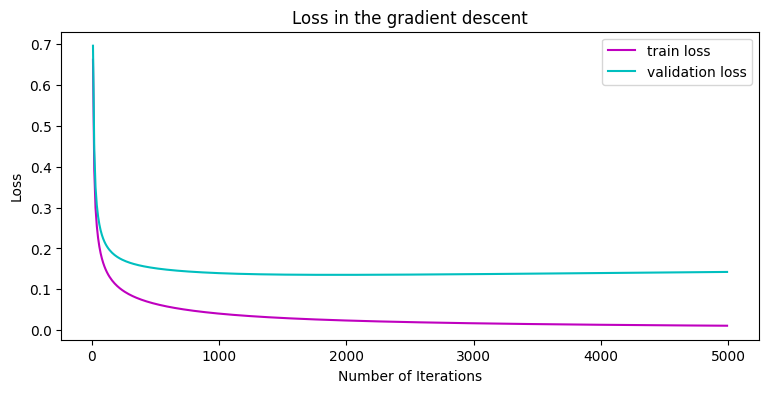

In [14]:
# initialize weights and bias
w_init = np.zeros((train_X.shape[1]+1, num_classes))
# create and initialize a instance of the class GradientDescent
GD = GradientDescent(w_init, learning_rate, train_X_offset, train_y)

Iterations = []
Train_losses = []
Validation_losses = []
Weights = []

for iter in range(1, 5000):
    # record the weights
    Weights.append(GD.w.copy())

    # train loss
    train_loss = GD.update()
    
    # validation loss
    f_new = LinearFunc(GD.w.copy())
    valid_lossfunc = LossFunc(f_new)
    valid_loss = valid_lossfunc(valid_X_offset, valid_y)
    
    if(iter % 10 == 0):
        Iterations.append(iter)
        Train_losses.append(train_loss)
        Validation_losses.append(valid_loss)
        print("Iteration: ",iter," Train Loss:", "%.4f" % train_loss, " Validation Loss:", "%.4f" % valid_loss)
loss_visualization(Iterations, Train_losses, Validation_losses)

#### <span style="color:red">[TODO]</span> Test the learned model on test dataset (4 pts)

According to the loss curve of validation dataset, do you notice some phenomenon discussed on the lecture before? By considering it, please decide which weights to use for the prediction first by simply specifying the index in `Weights`. Similarly, please also do some data processing for the test dataset and use the learned model for the prediction. 

According to the predicted likelihood, you have to pick the class with the highest probability as the result, which can be achieved by `np.argmax`.

In [15]:
##BEGIN SOLUTION
## A: Accordingly, overfitting is happening and roughly we only need to pick the weight around the iter 210 (not strictly).
w_opt = Weights[210]
test_X_offset = np.insert(test_X, 0, values=np.ones(test_X.shape[0]), axis=1)
###END SOLUTION

def prediction(X_offset, w):
    """
    return the predicted class for each test instance
    inputs:
        - X_offset (np.array): input X with an additional column with full ones at the very beginning
        - w (np.array): weights of the linear function, including the bias w0
    """
    ##BEGIN SOLUTION
    f = LinearFunc(w)
    y_hat = Softmax_Likelihood(f)
    y_predict = np.argmax(y_hat(X_offset),axis=1)
    ###END SOLUTION
    return y_predict
       

Now, you can simply run the following blocks by comparing the models with a full-zero weight and the weight you picked.

In [16]:
# fetch the very first from GD for comparison
candidate_weights = [Weights[0], w_opt]
Predictions = []
for weight in candidate_weights:
    Predictions.append(prediction(test_X_offset, weight))

By creating a confusion matrix for this model, how will you evaluate it?

In [17]:
from sklearn import metrics
for prediction in Predictions:
    confusion_mat = metrics.confusion_matrix(test_y, prediction)
    print(confusion_mat)

[[48  0  0  0  0  0  0  0  0  0]
 [48  0  0  0  0  0  0  0  0  0]
 [47  0  0  0  0  0  0  0  0  0]
 [53  0  0  0  0  0  0  0  0  0]
 [42  0  0  0  0  0  0  0  0  0]
 [40  0  0  0  0  0  0  0  0  0]
 [41  0  0  0  0  0  0  0  0  0]
 [47  0  0  0  0  0  0  0  0  0]
 [42  0  0  0  0  0  0  0  0  0]
 [42  0  0  0  0  0  0  0  0  0]]
[[47  0  0  0  0  1  0  0  0  0]
 [ 0 45  0  1  0  0  1  0  1  0]
 [ 0  0 46  0  0  0  0  1  0  0]
 [ 0  0  0 49  0  1  0  0  2  1]
 [ 0  0  0  0 39  0  0  2  0  1]
 [ 0  0  0  0  0 39  1  0  0  0]
 [ 0  1  0  0  0  0 40  0  0  0]
 [ 0  0  0  0  0  0  0 47  0  0]
 [ 0  1  0  0  0  0  0  0 41  0]
 [ 0  1  0  0  0  0  0  0  0 41]]


By visualizing the weights, you may have a more concrete feeling of which parts are put more attentions.

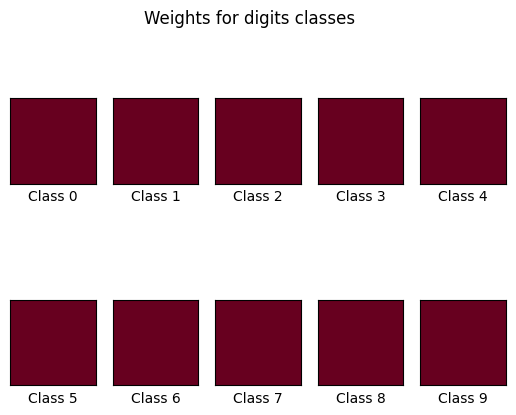

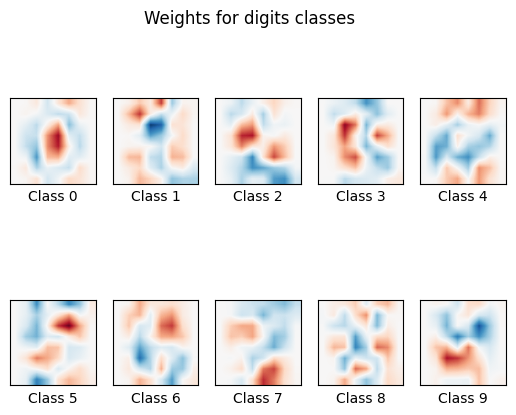

In [18]:
def weight_visualization(w):
    w = w[1:,:]
    scale = np.abs(w).max()
    for i in range(10): # 0-9
        weight_plot = plt.subplot(2, 5, i + 1) # 2x5 plot

        weight_plot.imshow(w[:, i].reshape(8,8), 
                        cmap=plt.cm.RdBu,
                        vmin=-scale, vmax=scale,
                        interpolation='bilinear')
        
        weight_plot.set_xticks(())
        weight_plot.set_yticks(())
        weight_plot.set_xlabel(f'Class {i}')

    plt.suptitle('Weights for digits classes')
    plt.show()
for weight in candidate_weights:
    weight_visualization(weight)